# Fast Food Restaurant - Sales Forecast
### End-to-End ML Pipeline | XGBoost | 7-Day Forecast

# 1 Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import warnings, os

warnings.filterwarnings("ignore")

# Plot styling
plt.rcParams.update({
    "figure.facecolor": "#f9f9f7",
    "axes.facecolor":   "#f9f9f7",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.spines.left": False,
    "axes.grid":        True,
    "grid.color":       "#e5e5e5",
    "grid.linewidth":   0.8,
    "font.family":      "sans-serif",
})

C = {
    "red":    "#E8593C",
    "blue":   "#3B8BD4",
    "green":  "#1D9E75",
    "amber":  "#EF9F27",
    "purple": "#8B5CF6",
}

print("Libraries imported")

Libraries imported


## 2 Load & Merge All 3 Data Sources

In [5]:
sales    = pd.read_csv("sales_data.csv")
calendar = pd.read_csv("calendar_events.csv")
weather  = pd.read_csv("weather_data.csv")

for frame in (sales, calendar, weather):
    frame["date"] = pd.to_datetime(frame["date"], dayfirst=True)

df = (sales
      .merge(calendar, on="date", how="left")
      .merge(weather,  on="date", how="left")
      .sort_values("date")
      .reset_index(drop=True))

print(f"Merged dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df.head()

Merged dataset: 1096 rows × 15 columns
   Date range: 2022-01-01 → 2024-12-31


,date,total_sales,transaction_count,avg_order_value,dine_in_sales,takeaway_sales,lunch_sales,dinner_sales,day,specials,holiday_for_adults,holiday_for_kids,temperature,humidity,sky_status
0,2022-01-01,4789.41,342,14.00,3064.26,1548.91,1751.01,2661.99,SAT,New Years Day,1,1,5.2,48,Sunny
1,2022-01-02,4275.11,300,14.25,2736.79,1736.60,1505.09,2765.96,SUN,NaN,0,0,-3.4,49,Sunny
2,2022-01-03,3715.49,288,12.90,2145.74,1284.21,1495.40,2204.01,MON,NaN,0,0,-0.0,70,Overcast
3,2022-01-04,3897.66,297,13.12,2501.43,1250.85,1478.05,2286.51,TUE,NaN,0,0,5.0,67,Rainy
4,2022-01-05,4163.82,322,12.93,2611.28,1619.15,1476.68,2543.07,WED,NaN,0,0,2.6,71,Rainy


## 3 Data Cleaning
Handle missing values, cap outliers, fill defaults.

In [7]:
before = len(df)

# Drop rows with no sales figure
df.dropna(subset=["total_sales"], inplace=True)

# Cap extreme outliers (beyond ±3 std)
mean_s, std_s = df["total_sales"].mean(), df["total_sales"].std()
n_outliers = ((df["total_sales"] < mean_s - 3*std_s) |
              (df["total_sales"] > mean_s + 3*std_s)).sum()
df["total_sales"] = df["total_sales"].clip(mean_s - 3*std_s, mean_s + 3*std_s)

# Fill missing weather & calendar
df["temperature"].fillna(df["temperature"].median(), inplace=True)
df["humidity"].fillna(df["humidity"].median(), inplace=True)
df["sky_status"].fillna("Cloudy", inplace=True)
df["specials"].fillna("", inplace=True)

df.reset_index(drop=True, inplace=True)

print(f"   Cleaning done")
print(f"   Rows removed     : {before - len(df)}")
print(f"   Outliers capped  : {n_outliers}")
print(f"   Remaining rows   : {len(df)}")
print(f"   Missing values   : {df.isnull().sum().sum()}")

   Cleaning done
   Rows removed     : 0
   Outliers capped  : 1
   Remaining rows   : 1096
   Missing values   : 0


## 4 Feature Engineering
Create all the signals the model will learn from.

In [9]:
# Time features
df["dow"]        = df["date"].dt.dayofweek        # 0=Mon, 6=Sun
df["month"]      = df["date"].dt.month
df["week"]       = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = (df["dow"] >= 5).astype(int)

# Lag features — what did we sell 1, 7, 14 days ago?
for lag in [1, 7, 14]:
    df[f"lag_{lag}"] = df["total_sales"].shift(lag)

# Rolling averages — recent trends
df["roll_7"]  = df["total_sales"].shift(1).rolling(7).mean()
df["roll_28"] = df["total_sales"].shift(1).rolling(28).mean()

# Event flags
df["has_special"]   = (df["specials"] != "").astype(int)
df["is_bank_hol"]   = df["specials"].str.contains(
    "Bank|Holiday|Jubilee|Coronation", case=False).astype(int)
df["is_valentines"] = df["specials"].str.contains("Valentine", case=False).astype(int)
df["is_christmas"]  = df["specials"].str.contains("Christmas|Boxing", case=False).astype(int)

# Weather — convert sky to numeric score
sky_map = {"Sunny":5, "Partly Cloudy":4, "Cloudy":3, "Overcast":2, "Rainy":1}
df["sky_score"] = df["sky_status"].map(sky_map).fillna(3)

# Drop early rows where lags/rolling can't be computed
df.dropna(subset=["lag_1","lag_7","lag_14","roll_7","roll_28"], inplace=True)
df.reset_index(drop=True, inplace=True)

FEATURES = [
    "dow", "month", "week", "is_weekend",
    "lag_1", "lag_7", "lag_14",
    "roll_7", "roll_28",
    "temperature", "humidity", "sky_score",
    "holiday_for_adults", "holiday_for_kids",
    "has_special", "is_bank_hol",
]

print(f"   Feature engineering complete")
print(f"   Features created : {len(FEATURES)}")
print(f"   Final dataset    : {len(df)} rows")
print(f"\n   Feature list:")
for i, f in enumerate(FEATURES, 1):
    print(f"   {i:>2}. {f}")

   Feature engineering complete
   Features created : 16
   Final dataset    : 1068 rows

   Feature list:
    1. dow
    2. month
    3. week
    4. is_weekend
    5. lag_1
    6. lag_7
    7. lag_14
    8. roll_7
    9. roll_28
   10. temperature
   11. humidity
   12. sky_score
   13. holiday_for_adults
   14. holiday_for_kids
   15. has_special
   16. is_bank_hol


## 5 Model Training
Train XGBoost on all data up to Oct 2024. Keep Nov–Dec 2024 for testing.

In [11]:
TRAIN_CUTOFF = pd.Timestamp("2024-10-31")

train = df[df["date"] <= TRAIN_CUTOFF].copy()
test  = df[df["date"] >  TRAIN_CUTOFF].copy()

X_train, y_train = train[FEATURES], train["total_sales"]
X_test,  y_test  = test[FEATURES],  test["total_sales"]

model = XGBRegressor(
    n_estimators     = 300,
    learning_rate    = 0.01,
    max_depth        = 5,
    subsample        = 0.9,
    colsample_bytree = 0.9,
    min_child_weight = 3,
    reg_alpha        = 0.1,
    reg_lambda       = 2.0,
    random_state     = 42,
)
model.fit(X_train, y_train, verbose=False)

print(" Model trained!")
print(f"   Training rows : {len(train):,}")
print(f"   Test rows     : {len(test):,}")
print(f"   Features used : {len(FEATURES)}")

 Model trained!
   Training rows : 1,007
   Test rows     : 61
   Features used : 16


## 6 Validation: Actual vs Predicted
How well does the model perform on data it has never seen?

  MODEL VALIDATION RESULTS
  MAE  (avg £ off per day)  : £158
  MAPE (avg % off per day)  : 4.0%
  Accuracy                  : 96.0%


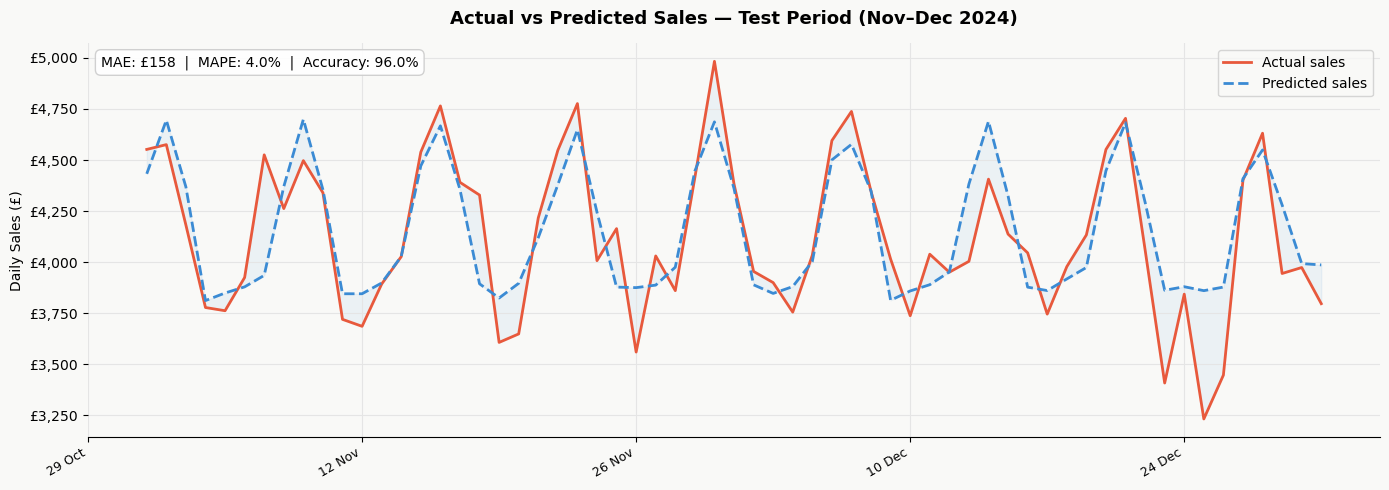

In [13]:
preds = model.predict(X_test)
test  = test.copy()
test["predicted"] = preds

mae  = mean_absolute_error(y_test, preds)
mape = (np.abs((y_test.values - preds) / y_test.values)).mean() * 100
acc  = 100 - mape

print("=" * 45)
print("  MODEL VALIDATION RESULTS")
print("=" * 45)
print(f"  MAE  (avg £ off per day)  : £{mae:,.0f}")
print(f"  MAPE (avg % off per day)  : {mape:.1f}%")
print(f"  Accuracy                  : {acc:.1f}%")
print("=" * 45)

# ── Chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test["date"], test["total_sales"],
        color=C["red"],  lw=2,   label="Actual sales",    zorder=3)
ax.plot(test["date"], test["predicted"],
        color=C["blue"], lw=2, ls="--", label="Predicted sales", zorder=3)
ax.fill_between(test["date"], test["total_sales"], test["predicted"],
                alpha=0.07, color=C["blue"])

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"£{x:,.0f}"))
ax.set_title("Actual vs Predicted Sales — Test Period (Nov–Dec 2024)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Daily Sales (£)")
ax.legend(fontsize=10)
ax.annotate(
    f"MAE: £{mae:,.0f}  |  MAPE: {mape:.1f}%  |  Accuracy: {acc:.1f}%",
    xy=(0.01, 0.97), xycoords="axes fraction", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#ccc", alpha=0.9),
    va="top"
)
plt.tight_layout()
plt.show()

## 7 Feature Importance
What is actually driving the sales predictions?

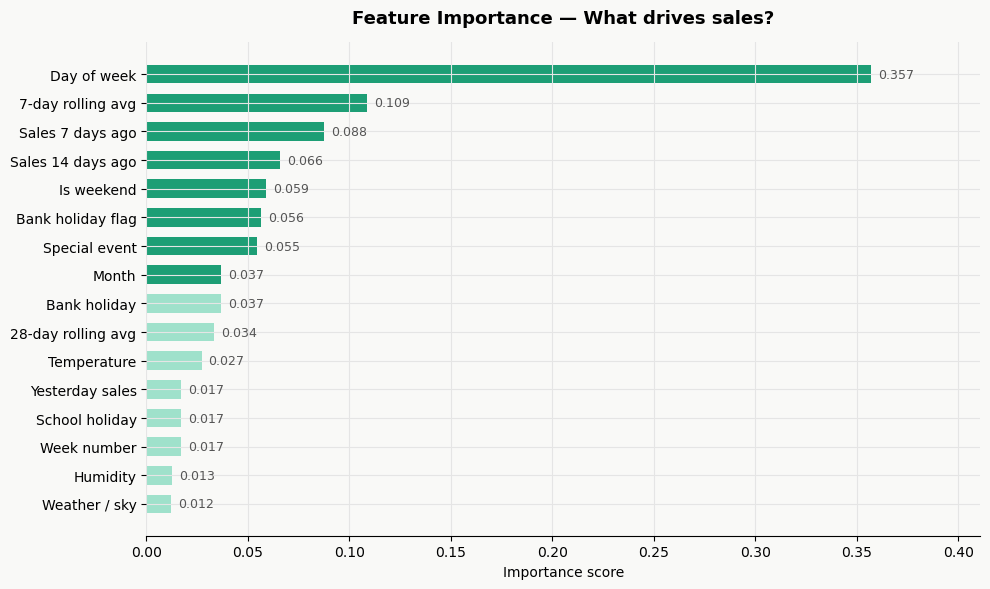


Top 5 drivers of sales:
   Day of week               0.3572
   7-day rolling avg         0.1087
   Sales 7 days ago          0.0875
   Sales 14 days ago         0.0661
   Is weekend                0.0592


In [15]:
label_map = {
    "roll_7":  "7-day rolling avg", "roll_28": "28-day rolling avg",
    "lag_1":   "Yesterday sales",   "lag_7":   "Sales 7 days ago",
    "lag_14":  "Sales 14 days ago", "dow":     "Day of week",
    "month":   "Month",             "week":    "Week number",
    "is_weekend":        "Is weekend",
    "temperature":       "Temperature",
    "humidity":          "Humidity",
    "sky_score":         "Weather / sky",
    "holiday_for_adults":"Bank holiday",
    "holiday_for_kids":  "School holiday",
    "has_special":       "Special event",
    "is_bank_hol":       "Bank holiday flag",
}

imp = (pd.Series(model.feature_importances_, index=FEATURES)
       .rename(label_map)
       .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
colors = [C["green"] if v > imp.median() else "#9FE1CB" for v in imp.values]
bars = ax.barh(imp.index, imp.values, color=colors, edgecolor="none", height=0.65)
ax.bar_label(bars, fmt="%.3f", padding=5, fontsize=9, color="#555")
ax.set_title("Feature Importance — What drives sales?",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Importance score")
ax.set_xlim(0, imp.values.max() * 1.15)
plt.tight_layout()
plt.show()

print("\nTop 5 drivers of sales:")
for name, val in imp.sort_values(ascending=False).head(5).items():
    print(f"   {name:<25} {val:.4f}")

## 8 7-Day Sales Forecast
**Edit the variables below** to match next week's expected conditions before running.


In [17]:
# ── EDIT THESE for next week ──────────────────────────────────
NEXT_WEEK_TEMP        = 14        # °C
NEXT_WEEK_HUMIDITY    = 60        # %
NEXT_WEEK_SKY         = "Cloudy"  # Sunny / Partly Cloudy / Cloudy / Overcast / Rainy
BANK_HOLIDAY          = False     # True if any bank holiday next week
SCHOOL_HOLIDAY        = False     # True if school / half-term
SPECIAL_EVENT         = False     # True if any event (football, festival, etc.)
# ─────────────────────────────────────────────────────────────

sky_map   = {"Sunny":5,"Partly Cloudy":4,"Cloudy":3,"Overcast":2,"Rainy":1}
sky_score = sky_map.get(NEXT_WEEK_SKY, 3)

known     = df["total_sales"].values.tolist()
last_date = df["date"].max()
future    = pd.date_range(last_date + pd.Timedelta(days=1), periods=7)

rows = []
for fd in future:
    row = {
        "dow":        fd.dayofweek,
        "month":      fd.month,
        "week":       int(fd.isocalendar().week),
        "is_weekend": int(fd.dayofweek >= 5),
        "lag_1":      known[-1],
        "lag_7":      known[-7],
        "lag_14":     known[-14],
        "roll_7":     np.mean(known[-7:]),
        "roll_28":    np.mean(known[-28:]),
        "temperature":        NEXT_WEEK_TEMP,
        "humidity":           NEXT_WEEK_HUMIDITY,
        "sky_score":          sky_score,
        "holiday_for_adults": int(BANK_HOLIDAY),
        "holiday_for_kids":   int(SCHOOL_HOLIDAY),
        "has_special":        int(SPECIAL_EVENT),
        "is_bank_hol":        int(BANK_HOLIDAY),
    }
    pred = float(model.predict(pd.DataFrame([row]))[0])
    rows.append({"date": fd, "day": fd.strftime("%A"), "forecast": round(pred, 2)})
    known.append(pred)

forecast_df = pd.DataFrame(rows)
week_total  = forecast_df["forecast"].sum()

print("=" * 48)
print("  7-DAY SALES FORECAST")
print("=" * 48)
for _, r in forecast_df.iterrows():
    bar = "█" * int(r["forecast"] / 250)
    print(f"  {r['day']:<10}  £{r['forecast']:>7,.0f}  {bar}")
print("-" * 48)
print(f"  WEEK TOTAL       £{week_total:>7,.0f}")
print("=" * 48)

  7-DAY SALES FORECAST
  Wednesday   £  4,020  ████████████████
  Thursday    £  4,015  ████████████████
  Friday      £  4,490  █████████████████
  Saturday    £  4,710  ██████████████████
  Sunday      £  4,354  █████████████████
  Monday      £  3,872  ███████████████
  Tuesday     £  3,887  ███████████████
------------------------------------------------
  WEEK TOTAL       £ 29,348


## 9 Forecast Chart
Visual 7-day forecast with confidence band and recent history.

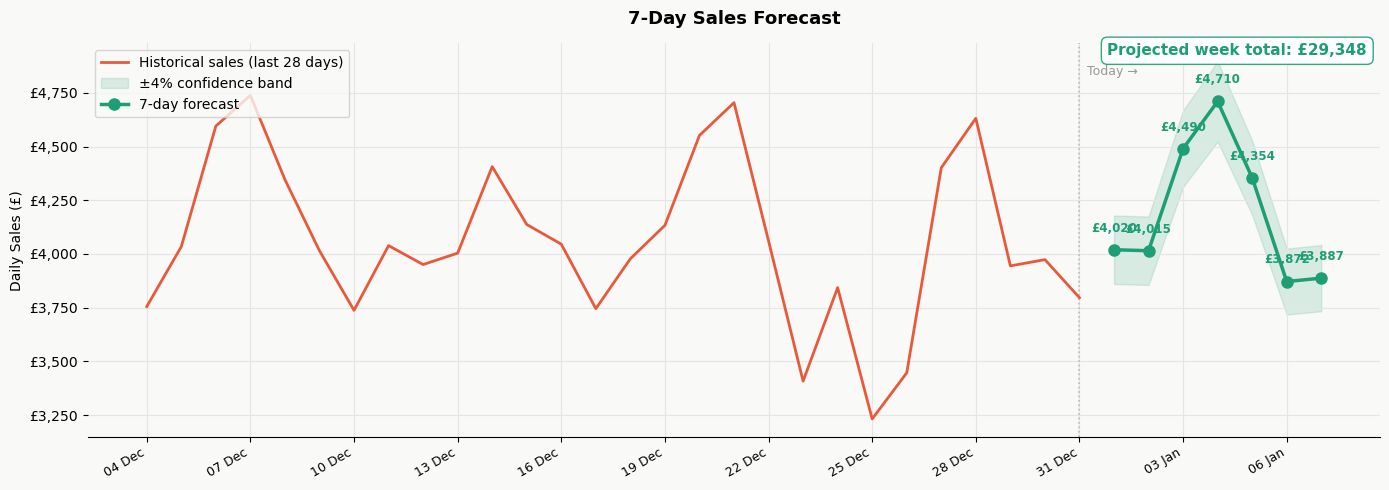

In [19]:
recent = df.tail(28)[["date","total_sales"]].copy()
band   = mape / 100

fig, ax = plt.subplots(figsize=(14, 5))

# Historical line
ax.plot(recent["date"], recent["total_sales"],
        color=C["red"], lw=2, label="Historical sales (last 28 days)", zorder=3)

# Confidence band
ax.fill_between(
    forecast_df["date"],
    forecast_df["forecast"] * (1 - band),
    forecast_df["forecast"] * (1 + band),
    color=C["green"], alpha=0.15, label=f"±{mape:.0f}% confidence band"
)

# Forecast line
ax.plot(forecast_df["date"], forecast_df["forecast"],
        color=C["green"], lw=2.5, marker="o", markersize=8,
        label="7-day forecast", zorder=4)

# Label each point
for _, r in forecast_df.iterrows():
    ax.annotate(f"£{r['forecast']:,.0f}",
                xy=(r["date"], r["forecast"]),
                xytext=(0, 13), textcoords="offset points",
                ha="center", fontsize=8.5, color=C["green"], fontweight="bold")

# Today divider
ax.axvline(last_date, color="#bbb", lw=1.2, ls=":", zorder=2)
ax.text(last_date, ax.get_ylim()[1] * 0.98,
        "  Today →", color="#999", fontsize=9, va="top")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"£{x:,.0f}"))
ax.set_title("7-Day Sales Forecast", fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Daily Sales (£)")
ax.legend(fontsize=10, loc="upper left")
ax.annotate(
    f"Projected week total: £{week_total:,.0f}",
    xy=(0.99, 0.97), xycoords="axes fraction", ha="right",
    fontsize=11, fontweight="bold", color=C["green"],
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=C["green"], alpha=0.9)
)
plt.tight_layout()
plt.show()

## 10 - Day of Week Sales Pattern
Which days are busiest? Useful for rostering.

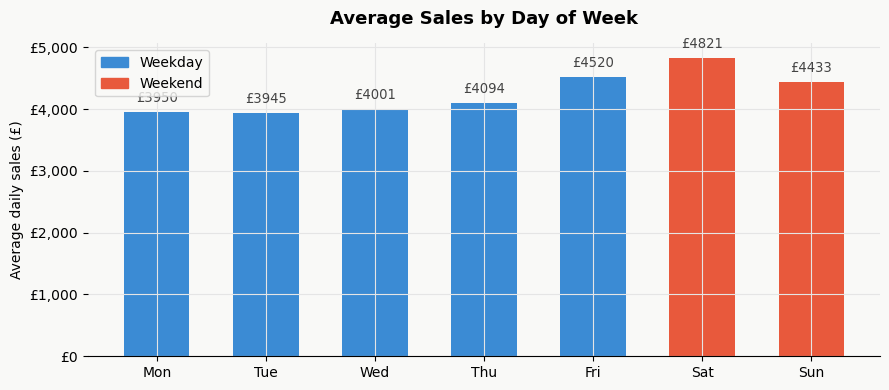

Busiest day  : Sat (avg £4,821)
Quietest day : Tue (avg £3,945)


In [21]:
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_avg    = df.groupby("dow")["total_sales"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [C["red"] if i >= 5 else C["blue"] for i in range(7)]
bars = ax.bar(dow_labels, dow_avg, color=bar_colors, edgecolor="none", width=0.6)
ax.bar_label(bars, fmt="£%.0f", padding=5, fontsize=9.5, color="#444")
ax.set_title("Average Sales by Day of Week", fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Average daily sales (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"£{x:,.0f}"))

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=C["blue"], label="Weekday"),
                   Patch(color=C["red"],  label="Weekend")], fontsize=10)
plt.tight_layout()
plt.show()

print(f"Busiest day  : {dow_labels[dow_avg.idxmax()]} (avg £{dow_avg.max():,.0f})")
print(f"Quietest day : {dow_labels[dow_avg.idxmin()]} (avg £{dow_avg.min():,.0f})")

## 11 Monthly Sales Trend (3-year overview)
Shows seasonality and year-on-year growth.

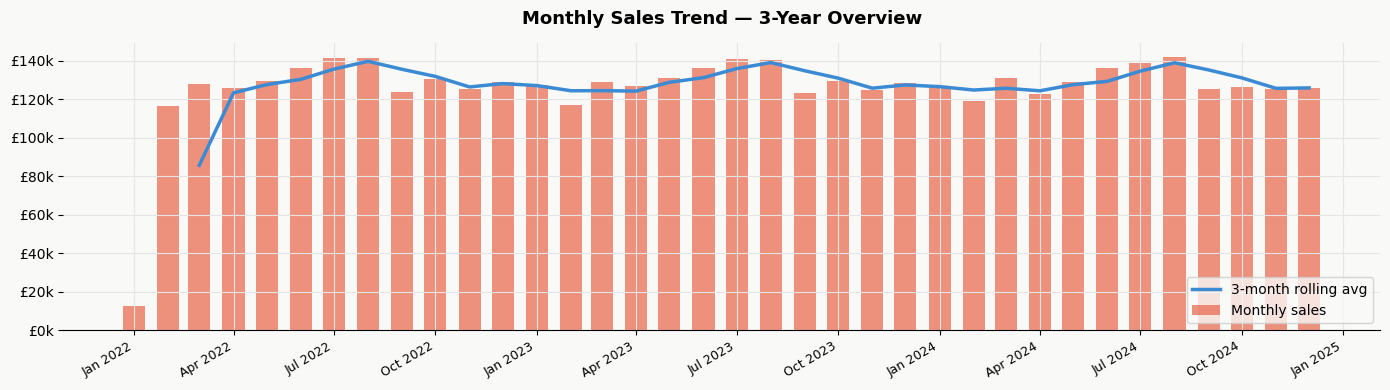

Best month  : August 2024  — £141,908
Worst month : January 2022 — £12,735


In [23]:
monthly = (df.groupby(df["date"].dt.to_period("M"))["total_sales"]
             .sum().reset_index())
monthly["date"]  = monthly["date"].dt.to_timestamp()
monthly["roll3"] = monthly["total_sales"].rolling(3).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly["date"], monthly["total_sales"],
       width=20, color=C["red"], alpha=0.65, edgecolor="none", label="Monthly sales")
ax.plot(monthly["date"], monthly["roll3"],
        color=C["blue"], lw=2.5, label="3-month rolling avg")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"£{x/1000:,.0f}k"))
ax.set_title("Monthly Sales Trend — 3-Year Overview", fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

best  = monthly.loc[monthly["total_sales"].idxmax()]
worst = monthly.loc[monthly["total_sales"].idxmin()]
print(f"Best month  : {best['date'].strftime('%B %Y')}  — £{best['total_sales']:,.0f}")
print(f"Worst month : {worst['date'].strftime('%B %Y')} — £{worst['total_sales']:,.0f}")

## 12 - Summary Dashboard
Key numbers at a glance - useful for a pitch.

In [25]:
print("=" * 55)
print("  FORECAST SUMMARY")
print("=" * 55)
print(f"  Data range       : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Training rows    : {len(train):,} days")
print(f"  Model accuracy   : {acc:.1f}%  (MAPE {mape:.1f}%)")
print(f"  MAE              : ±£{mae:,.0f} per day")
print()
print(f"  Avg daily sales  : £{df['total_sales'].mean():,.0f}")
print(f"  Best single day  : £{df['total_sales'].max():,.0f}")
print(f"  Worst single day : £{df['total_sales'].min():,.0f}")
print()
print(f"  NEXT WEEK FORECAST")
for _, r in forecast_df.iterrows():
    print(f"    {r['day']:<10} £{r['forecast']:>7,.0f}")
print(f"    {'TOTAL':<10} £{week_total:>7,.0f}")
print("=" * 55)

  FORECAST SUMMARY
  Data range       : 2022-01-29 → 2024-12-31
  Training rows    : 1,007 days
  Model accuracy   : 96.0%  (MAPE 4.0%)
  MAE              : ±£158 per day

  Avg daily sales  : £4,252
  Best single day  : £5,497
  Worst single day : £3,206

  NEXT WEEK FORECAST
    Wednesday  £  4,020
    Thursday   £  4,015
    Friday     £  4,490
    Saturday   £  4,710
    Sunday     £  4,354
    Monday     £  3,872
    Tuesday    £  3,887
    TOTAL      £ 29,348
